In [23]:
from collections import defaultdict, namedtuple
from dataclasses import dataclass
from datetime import date, datetime, timedelta
from decimal import Decimal
from statistics import mean
import json
import random
import toml

import matplotlib.dates as pltd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
import seaborn as sns

from sqlalchemy import create_engine
from sqlalchemy import desc, asc
from sqlalchemy import select, and_, or_
from sqlalchemy.orm import Session, lazyload, joinedload

from ss13tools.settings import make_engine
from ss13tools.model import Round, Feedback, LegacyPopulation

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

local_engine = make_engine("settings_local.toml")
local_session = Session(local_engine)

# Analyzing Production Ruin Frequency vs Simulation

The data we're getting from prod and the data we're getting from test are slightly different in an important way: the prod data was produced in real-time over the course of a month, and the test rounds were all rapid-fire, one after another, over the course of a day, with each round taking about 38 seconds to spin up, generate ruins, write the ruin data to disk, and restart.

This is after several balance features in, so we choose a month-long range that matches the features/reworks/loot changes we care about:

| Feature               | Date       |
| --------------------- | ---------- |
| Deepstorage Rework    | 2024-07-30 |
| Explorer Rework       | 2024-05-27 |
| DVORAK Ruin           | 2024-07-25 |
| Tarot Cards           | 2024-04-24 |
| Mech Transport Rework | 2024-03-21 |
| Rocky Motel           | 2024-06-12 |
| Casino                | 2024-06-29 |
| Abandoned Sec Shuttle | 2024-08-04 |
 | |

In [3]:
query = session.query(Feedback.datetime, Feedback.json).join(Round).filter(
        Feedback.key_name == 'ruin_placement',
        Round.start_datetime >= datetime(2024, 8, 5),
        Round.start_datetime < datetime(2024, 9, 5))

raw_prod_ruins = pd.read_sql_query(query.statement, session.connection())

The test rounds started at ID 3600, so we grab as many as there were real rounds.

In [4]:
query = local_session.query(Feedback.json).join(Round).filter(
    Feedback.key_name == 'ruin_placement',
    Round.id > 3600).limit(len(raw_prod_ruins))

raw_test_ruins = pd.read_sql_query(query.statement, local_session.connection())

In [24]:
raw_prod_ruins

,datetime,json
0,2024-08-05 00:42:48,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
1,2024-08-05 02:18:58,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
2,2024-08-05 04:37:40,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
3,2024-08-05 07:03:09,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
4,2024-08-05 09:21:10,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
...,...,...
370,2024-09-04 18:44:11,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
371,2024-09-04 18:59:03,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
372,2024-09-04 21:18:09,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
373,2024-09-04 23:06:36,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."


In [25]:
raw_test_ruins

,json
0,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
1,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
2,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
3,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
4,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
...,...
370,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
371,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
372,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."
373,"{'data': {'1': {'map': 'spacebar.dmm', 'coords..."


## Selecting Ruins

Create the list of ruins we're looking at. Can be a lot or a little.

In [5]:
problem_ruins = [
    "abandoned_sec_shuttle.dmm",
    "abandonedzoo.dmm",
    "blowntcommsat.dmm",
    "casino.dmm",
    "deepstorage.dmm",
    "derelict3.dmm", # space dragon
    "derelict5.dmm",
    "dj.dmm",
    "intactemptyship.dmm",
    "listeningpost.dmm",
    "meatpackers.dmm",
    "mechtransport.dmm",
    "onehalf.dmm",
    "rocky_motel.dmm",
    "syndicatedruglab.dmm",
    "syndiecakesfactory.dmm",
    "telecomns_returns.dmm",
    "turretedoutpost.dmm",
    "ussp_tele.dmm",
    "ussp.dmm",
    "wizardcrash.dmm",
    "wreckedcargoship.dmm",
]
ruin_shortnames = [x.replace('.dmm', '') for x in problem_ruins]

## Processing Feedback JSON

These functions are applied to dataframes with feedback JSON data to either get the sum total of ruins spawned during a round, or the discrete count of each ruin we care about. After we apply these functions we typically drop the JSON column so it doesn't make the remaining work challenging.

In [6]:
def apply_total_ruin_count(text):
    keys, values = zip(*[("total", sum(1 for ruin in text['data'].values() if ruin["map"] in problem_ruins))])
    return pd.Series(values, index=keys)

def get_total_ruin_count(df):
    return pd.concat([df, df['json'].apply(apply_total_ruin_count)], axis=1).drop(['json'], axis=1)
    
def apply_individual_ruin_counts(text):
    keys, values = zip(*[(p.replace('.dmm', ''), sum(1 for ruin in text['data'].values() if ruin["map"] == p)) for p in problem_ruins])
    return pd.Series(values, index=keys)

def get_individual_ruin_counts(df):
    return pd.concat([df, raw_prod_ruins['json'].apply(apply_individual_ruin_counts)], axis=1).drop(['json'], axis=1)

In [7]:
test_total_ruin_count = get_total_ruin_count(raw_test_ruins)
prod_dated_ruin_count = get_total_ruin_count(raw_prod_ruins)
prod_dated_ruin_count['datetime'] = pd.to_datetime(prod_dated_ruin_count['datetime']).dt.date

## Normalizing Data

Now we're going to try and make the tables consistent in data. This means we need to remove time values from the prod counts, only leaving the dates, and add dates to the test counts.

Comparing results in terms of "days" isn't a necessarily meaningful measurement but it's useful for an approximation of what the overall results might look like, without having to dive into the precision of per-round statistics (although we do that later when generating our histograms).

So we find out how many rounds were run each day of the month and create a cumulative array of them in order to bucket the test runs into those ranges. We also create a dataframe keying those buckets to their respective dates. In other words, if there were 11 rounds on the first day in real life, then the range for the first simulated day will be (0, 11].

In [8]:
def create_summed_dates(df):
    firstday = datetime.fromisoformat("2024-08-05")
    rounds_per_day = df.resample('1d', on='datetime').apply({'json': 'count'})['json'].to_list()
    cumulative_rounds = np.cumsum([0] + rounds_per_day)
    return pd.DataFrame({
        'val': [x for i, x in enumerate(cumulative_rounds)],
        'dt': [firstday + timedelta(days=i) for i, x in enumerate(cumulative_rounds)],
    })

summed_dates = create_summed_dates(raw_prod_ruins)

This probably incredibly inefficient but I couldn't figure out a better way to do it, despite many attempts. As above, we wish to bucket every row in the test data into an interval that acts as its simulated date. Then we want to get the real dates by looking them up in the summed data, and then returning the date when the index of the summed data row is within the range in our round data.

In [9]:
def assign_date_by_range(row):
    for r in summed_dates.iterrows():
        val = r[1].val
        dt = r[1]["dt"]
        if val >= row.range.left and val <= row.range.right:
            return dt

def from_range_to_date(df):
    return pd.concat([df.apply(assign_date_by_range, axis=1).rename('datetime'), df], axis=1).drop(['range'], axis=1)

test_total_ruin_count["range"] =  pd.cut(test_total_ruin_count.index.values, bins=summed_dates.val.values, right=True, include_lowest=True)
test_dated_ruin_count = from_range_to_date(test_total_ruin_count)

In [10]:
prod_dated_ruin_count

,datetime,total
0,2024-08-05,8
1,2024-08-05,9
2,2024-08-05,5
3,2024-08-05,8
4,2024-08-05,13
...,...,...
370,2024-09-04,10
371,2024-09-04,9
372,2024-09-04,6
373,2024-09-04,7


In [11]:
test_dated_ruin_count

,datetime,total
0,2024-08-05,6
1,2024-08-05,10
2,2024-08-05,7
3,2024-08-05,11
4,2024-08-05,7
...,...,...
370,2024-09-04,9
371,2024-09-04,8
372,2024-09-04,8
373,2024-09-04,8


## Visualization

Now our data is the same shape, we can start performing comparisons on it. First, we may want to see how many ruins were spawned every day/simulated day.

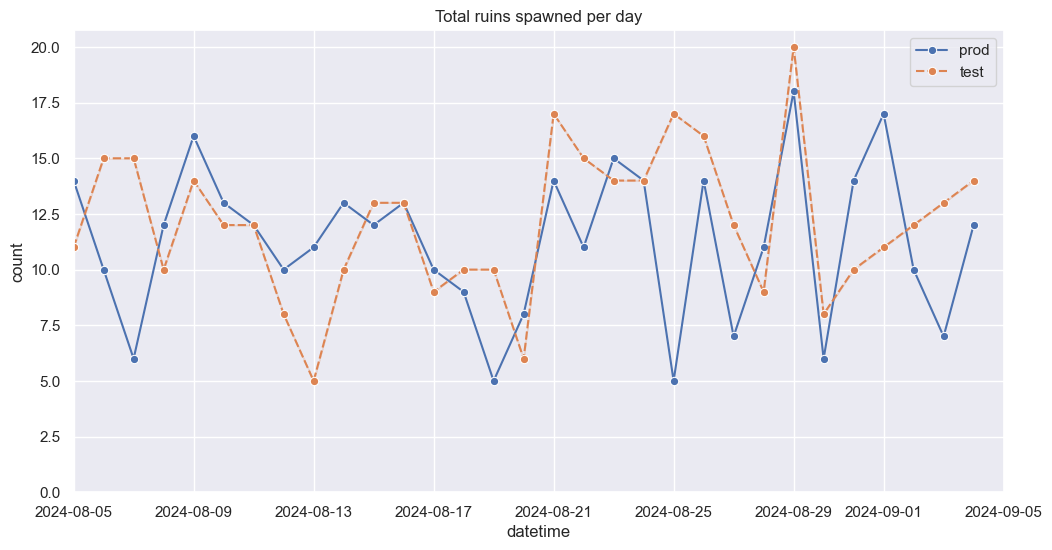

In [20]:
sns.set_theme()

def ruins_daily_sum_data(prod, test):
    data = dict()
    data['prod'] = prod.groupby(['datetime'])['total'].sum()
    data['test'] = test.groupby(['datetime'])['total'].sum()
    return data

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

sns.lineplot(data=ruins_daily_sum_data(prod_dated_ruin_count, test_dated_ruin_count), marker='o')

ax.set(ylabel='count')
ax.set(title='Total ruins spawned per day')
plt.xlim(date(2024, 8, 5), date(2024, 9, 5))
ax.set_ylim(ymin=0)
plt.savefig('ruins_daily_sum.png')

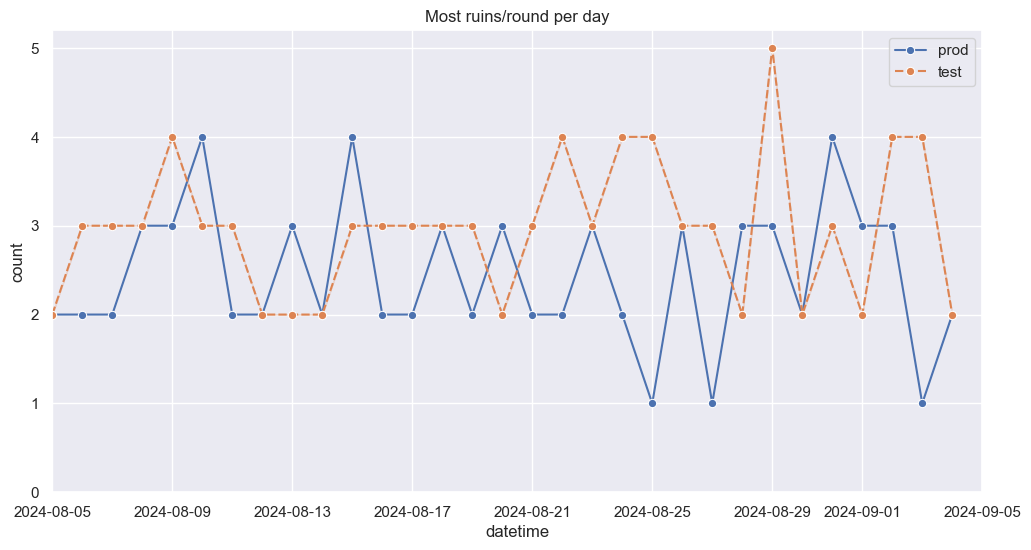

In [21]:
def ruins_daily_max_data(prod, test):
    data = dict()
    data['prod'] = prod.groupby(['datetime'])['total'].max()
    data['test'] = test.groupby(['datetime'])['total'].max()
    return data

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

sns.lineplot(data=ruins_daily_max_data(prod_dated_ruin_count, test_dated_ruin_count), marker='o')

ax.set(ylabel='count')
ax.set(title='Most ruins/round per day')
plt.xlim(date(2024, 8, 5), date(2024, 9, 5))
ax.set_ylim(ymin=0)
plt.savefig('ruins_daily_max.png')

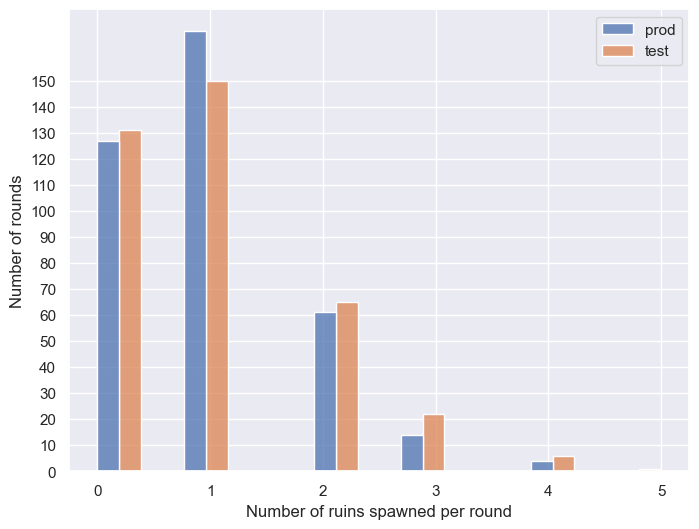

In [22]:
def get_histogram_data(test, prod):
    data = dict()
    data['prod'] = prod['total']
    data['test'] = test['total']
    return data
    
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)

ax.locator_params(axis='x', integer=True)
ax.set_xlabel("Number of ruins spawned per round")
ax.set_ylabel("Number of rounds")
ax.yaxis.set_ticks(np.arange(0, 160, 10))
ax.xaxis.set_ticks(np.arange(0, 18, 1))
sns.histplot(data=get_histogram_data(test_dated_ruin_count, prod_dated_ruin_count), multiple='dodge', bins=13)

plt.savefig('ruin_spawn_count_histogram.png')

In [15]:
problem_ruins = [
    "abandoned_sec_shuttle.dmm",
    "asteroid1.dmm",
]
ruin_shortnames = [x.replace('.dmm', '') for x in problem_ruins]

In [16]:
test_total_ruin_count = get_total_ruin_count(raw_test_ruins)
prod_dated_ruin_count = get_total_ruin_count(raw_prod_ruins)
prod_dated_ruin_count['datetime'] = pd.to_datetime(prod_dated_ruin_count['datetime']).dt.date
test_total_ruin_count["range"] =  pd.cut(test_total_ruin_count.index.values, bins=summed_dates.val.values, right=True, include_lowest=True)
test_dated_ruin_count = from_range_to_date(test_total_ruin_count)

In [17]:
max_bin = max(prod_dated_ruin_count['total'].max(), test_dated_ruin_count['total'].max())
min_bin = min(prod_dated_ruin_count['total'].min(), test_dated_ruin_count['total'].min())

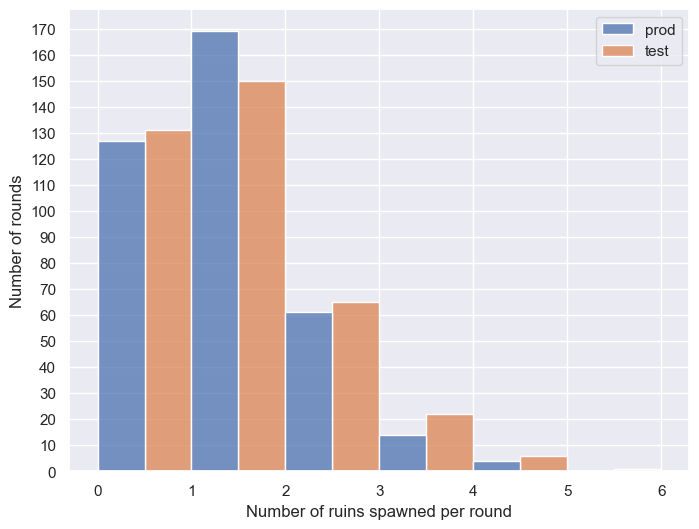

In [19]:
sns.set_theme()
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)

ax.locator_params(axis='x', integer=True)
ax.set_xlabel("Number of ruins spawned per round")
ax.set_ylabel("Number of rounds")
ax.yaxis.set_ticks(np.arange(0, 180, 10))
sns.histplot(data=get_histogram_data(test_dated_ruin_count, prod_dated_ruin_count), multiple='dodge', bins=[0, 1, 2, 3, 4, 5, 6])

plt.savefig('ruin_spawn_count_histogram.png')

In [128]:
problem_ruins = [
    "ussp.dmm",
    "telecomns_returns.dmm",
]
ruin_shortnames = [x.replace('.dmm', '') for x in problem_ruins]

In [129]:
test_total_ruin_count = get_total_ruin_count(raw_test_ruins)
prod_dated_ruin_count = get_total_ruin_count(raw_prod_ruins)
prod_dated_ruin_count['datetime'] = pd.to_datetime(prod_dated_ruin_count['datetime']).dt.date
test_total_ruin_count["range"] =  pd.cut(test_total_ruin_count.index.values, bins=summed_dates.val.values, right=True, include_lowest=True)
test_dated_ruin_count = from_range_to_date(test_total_ruin_count)

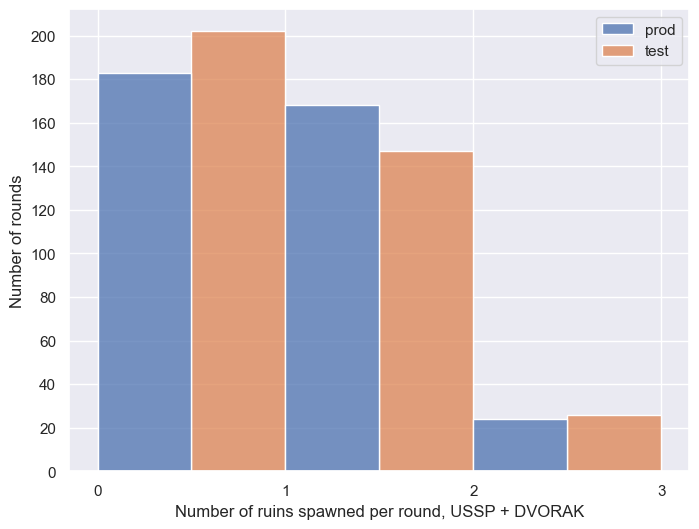

In [146]:
sns.set_theme()
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)
ax.locator_params(axis='x', integer=True)
ax.set_xlabel("Number of ruins spawned per round, USSP + DVORAK")
ax.set_ylabel("Number of rounds")
ax.yaxis.set_ticks(np.arange(0, 250, 20))
sns.histplot(data=get_histogram_data(test_dated_ruin_count, prod_dated_ruin_count), multiple='dodge', bins=[0, 1, 2, 3])
plt.savefig('ruin_spawn_count_histogram_ussp_dvorak.png')